In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import os, warnings
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn. linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error , r2_score
from sklearn.pipeline import make_pipeline

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt. rcParams["figure.figsize"] = (10, 5)
pd. set_option("display.width", 140); pd.set_option("display.max_columns", 40)
RANDOM_STATE = 42

Load the data set and perform EDA

In [2]:
df = pd.read_csv("house_price_50k.csv")
df.head()
df.shape
df.columns
df.info()
df.isnull().sum()
(df. isnull().sum() / len(df)) * 100
df.duplicated().sum()
df.describe()
df.describe(include='all')
df.select_dtypes(include=np.number).columns
df.select_dtypes(include='object').columns

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   area                  50000 non-null  int64  
 1   bedrooms              50000 non-null  int64  
 2   bathrooms             50000 non-null  int64  
 3   floors                50000 non-null  int64  
 4   age                   50000 non-null  int64  
 5   distance              50000 non-null  int64  
 6   garage                50000 non-null  int64  
 7   parking               50000 non-null  int64  
 8   garden                50000 non-null  int64  
 9   security              50000 non-null  int64  
 10  school_nearby         50000 non-null  int64  
 11  hospital_nearby       50000 non-null  int64  
 12  shopping_mall_nearby  50000 non-null  int64  
 13  public_transport      50000 non-null  int64  
 14  crime_rate            50000 non-null  float64
 15  population_density    50000 no

Index(['location', 'income_level'], dtype='str')

House Price Distribution

In [3]:
df.columns.tolist()

['area',
 'bedrooms',
 'bathrooms',
 'floors',
 'age',
 'distance',
 'garage',
 'parking',
 'garden',
 'security',
 'school_nearby',
 'hospital_nearby',
 'shopping_mall_nearby',
 'public_transport',
 'crime_rate',
 'population_density',
 'location',
 'income_level',
 'price']

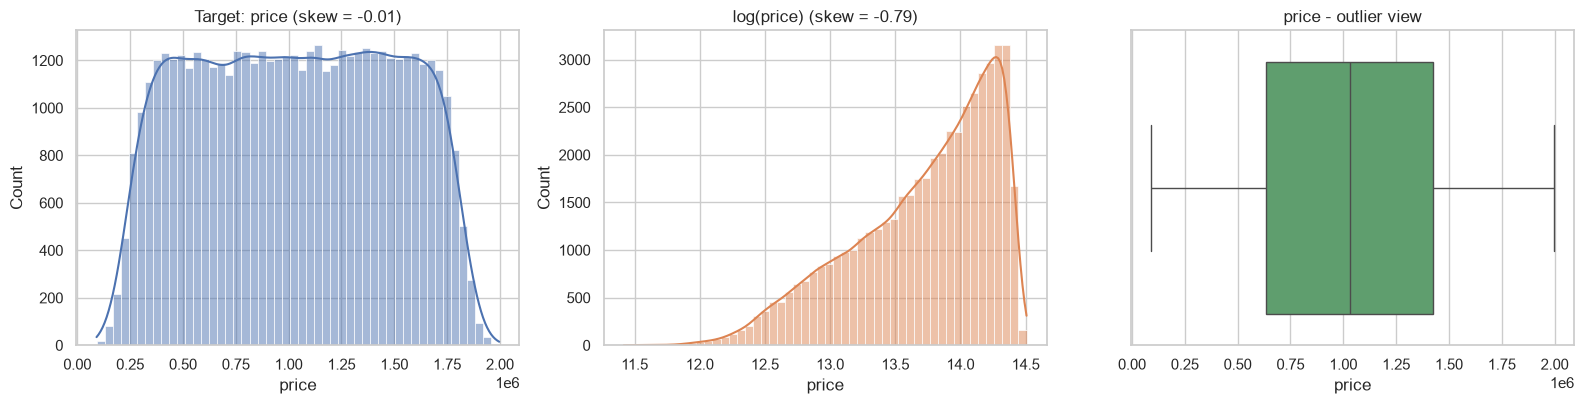

price: mean 1,030,261 | median 1,031,763 | std 458,020


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
sns.histplot(df["price"], bins=50, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title(f"Target: price (skew = {df['price'].skew():.2f})")
sns.histplot(np.log(df["price"]), bins=50, kde=True, ax=axes[1], color="#DD8452")
axes[1].set_title(f"log(price) (skew = {np.log(df['price']).skew():.2f})")
sns.boxplot(x=df["price"], ax=axes[2], color="#55A868")
axes[2].set_title("price - outlier view")
plt.tight_layout(); plt.show()
print("price: mean {:,.0f} | median {:,.0f} | std {:,.0f}". format(df['price'].mean(), df['price'].median(), df['price'].std()))

Observation: The price data looks almost normally distributed, with mean and median values being very close. The skewness is nearly Zero,so there is no major skewness in the original price data.

Feature Selection reasoning before modeling

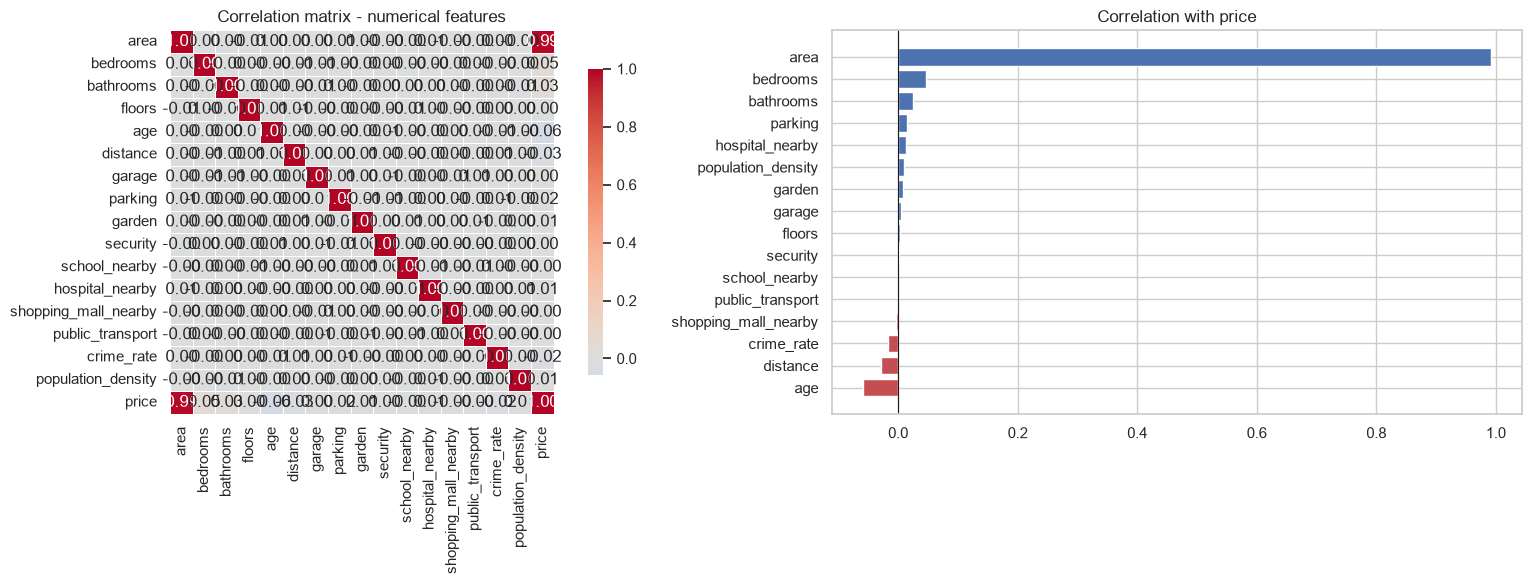

area                    0.991
bedrooms                0.047
bathrooms               0.026
parking                 0.015
hospital_nearby         0.014
population_density      0.011
garden                  0.009
garage                  0.005
floors                  0.003
security                0.002
school_nearby          -0.000
public_transport       -0.001
shopping_mall_nearby   -0.003
crime_rate             -0.017
distance               -0.028
age                    -0.059
Name: price, dtype: float64


In [5]:
num_df = df. select_dtypes(include=np.number)
corr = num_df.corr()
fig, axes= plt.subplots(1, 2, figsize=(17, 6))
sns.heatmap(corr , annot=True, fmt=".2f" , cmap="coolwarm", center=0, ax=axes[0], square=True, linewidths=0.4, cbar_kws={"shrink": 0.8})
axes[0].set_title("Correlation matrix - numerical features")
price_corr = corr["price"].drop("price").sort_values()
axes[1].barh(price_corr.index, price_corr.values, color=["#C44E52" if v <0 else"#4C72B0" for v in price_corr.values])
axes[1].set_title("Correlation with price"); axes[1].axvline(0, color="k", lw=.8)
plt.tight_layout(); plt.show()
print(corr["price"].drop("price").sort_values(ascending=False).round(3))

Observation: From the correlation analysis ,area has the strongest relationship with the price(0.991). This means that as the area increases, the price also increases significantly.

Missing values and One-Hot Encoding

In [6]:
data = df.copy()
# --- missing values, with a stated reason for each choice ---
data["area"] = data["area"].fillna(data["area"].median())            #skewed
data["parking"] = data["parking"].fillna(0)
if "heating" in data:
    data["heating"] = data["heating"].fillna(data["heating"].mode()[0])  # categorical -- mode
print( "Nulls remaining:", data.isna().sum().sum())   
# --- one hot encoding with drop_first to avoid the dummy variable trap ---
cat_cols = data.select_dtypes(include=["object", "category"]).columns.tolist()
print("Categorical colums:", cat_cols)
data = pd.get_dummies(data, columns=cat_cols, drop_first=True, dtype=float)
print(f"\ncols: {df.shape[1]} -. {data.shape[1]} after encoding ")
print([c for c in data.columns if any(c.startswith(p + '_') for p in cat_cols)])
data.head()


Nulls remaining: 0
Categorical colums: ['location', 'income_level']

cols: 19 -. 21 after encoding 
['location_medium', 'location_premium', 'income_level_low', 'income_level_mid']


,area,bedrooms,bathrooms,floors,age,distance,garage,parking,garden,security,school_nearby,hospital_nearby,shopping_mall_nearby,public_transport,crime_rate,population_density,price,location_medium,location_premium,income_level_low,income_level_mid
0,1360,6,2,2,9,10,0,0,1,0,1,0,1,0,6.939333,7242,5.952493e+05,0.0,1.0,1.0,0.0
1,4272,5,2,3,24,8,1,0,0,1,1,1,1,0,0.400918,7729,1.571208e+06,0.0,0.0,1.0,0.0
2,3592,1,4,3,4,20,0,1,1,1,0,1,0,1,6.292386,1081,1.379943e+06,0.0,1.0,0.0,1.0
3,966,5,2,2,6,14,1,0,0,0,0,1,1,0,8.964112,8912,4.367819e+05,1.0,0.0,1.0,0.0
4,4926,4,3,1,18,9,0,0,0,0,1,0,1,1,2.843309,8146,1.792425e+06,0.0,0.0,0.0,1.0


Train/test split and model training

In [7]:
X = data. drop(columns="price")
y = data["price"]
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape} | test: {X_test.shape}")
lin = LinearRegression()
lin.fit(X_train, y_train)
#a second model on log(price), to be judged on residuals
lin_log = LinearRegression()
lin_log.fit(X_train, np.log(y_train))
print("\nModels fitted: LinerRegression on price, and o log(price)")
print("Intercept:", round(lin.intercept_, 2))

Train: (40000, 20) | test: (10000, 20)

Models fitted: LinerRegression on price, and o log(price)
Intercept: 50118.15


Evaluation - MSE, RMSE.R^2

In [8]:
def evaluate(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np. sqrt(mse)
    return {"Model": name, "MSE": mse, "RMSE": rmse, "MAE": mean_absolute_error(y_true, y_pred),  "R": r2_score(y_true, y_pred), "MAPE %": np.mean(np.abs((y_true - y_pred) / y_true)) *100}
y_pred =lin.predict(X_test)
y_pred_log = np.exp(lin_log.predict(X_test))
rows = [evaluate("Linear Regression (price)", y_test, y_pred), evaluate("Linear Regression (Log price)", y_test, y_pred_log)]
res = pd.DataFrame(rows).set_index("Model")
print(res.round(3).to_string(float_format=lambda v: f"{v:,.3f}"))
cv = cross_val_score(LinearRegression(), X, y, cv=KFold(5, shuffle=True, random_state= RANDOM_STATE), scoring="r2")
print(f"\n5-fold CV R2: {cv.mean():.4f} (+/- {cv.std():.4f})")
print(f"Train R2: {lin.score(X_train, y_train):.4f} | Test R2: {lin.score(X_test, y_test):.4f}")

    

                                             MSE        RMSE         MAE     R  MAPE %
Model                                                                                 
Linear Regression (price)        397,637,450.315  19,940.849  15,954.173 0.998   2.086
Linear Regression (Log price) 19,183,055,526.968 138,502.908 106,119.549 0.909  11.771

5-fold CV R2: 0.9981 (+/- 0.0000)
Train R2: 0.9981 | Test R2: 0.9981


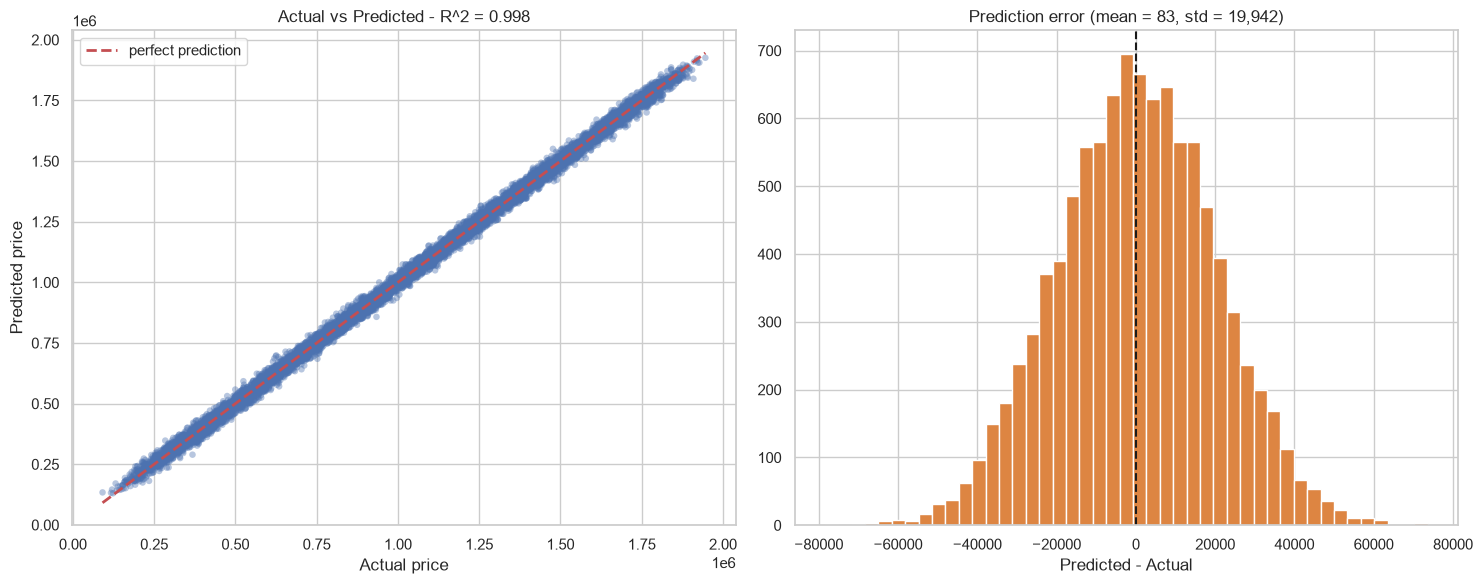

Predictions within 10% of actual: 98.3%
Predictions within 20% of actual: 99.9%


In [18]:
fig , axes = plt.subplots(1, 2, figsize=(15, 6))
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(),y_test.max(), y_pred.max())]
axes[0].scatter(y_test, y_pred, alpha=.4, s=22, color="#4C72B0", edgecolor="none")
axes[0].plot(lims, lims, "r--", lw=2, label="perfect prediction")
axes[0].set_xlabel("Actual price"); axes[0].set_ylabel("Predicted price")
axes[0].set_title(f"Actual vs Predicted - R^2 = {r2_score(y_test, y_pred):.3f}")
axes[0].legend()
err = y_pred - y_test
axes[1].hist(err, bins=45, color="#DD8542", edgecolor="white")
axes[1].axvline(0, color="k" , ls="--")
axes[1].set_title(f"Prediction error (mean = {err.mean():.0f}, std = {err.std():,.0f})")
axes[1].set_xlabel("Predicted - Actual")
plt.tight_layout(); plt.show()
within = lambda p: np.mean(np.abs(err) / y_test < p)
print(f"Predictions within 10% of actual: {within(.10):.1%}")
print(f"Predictions within 20% of actual: {within(.20):.1%}")

Residual Analysis 

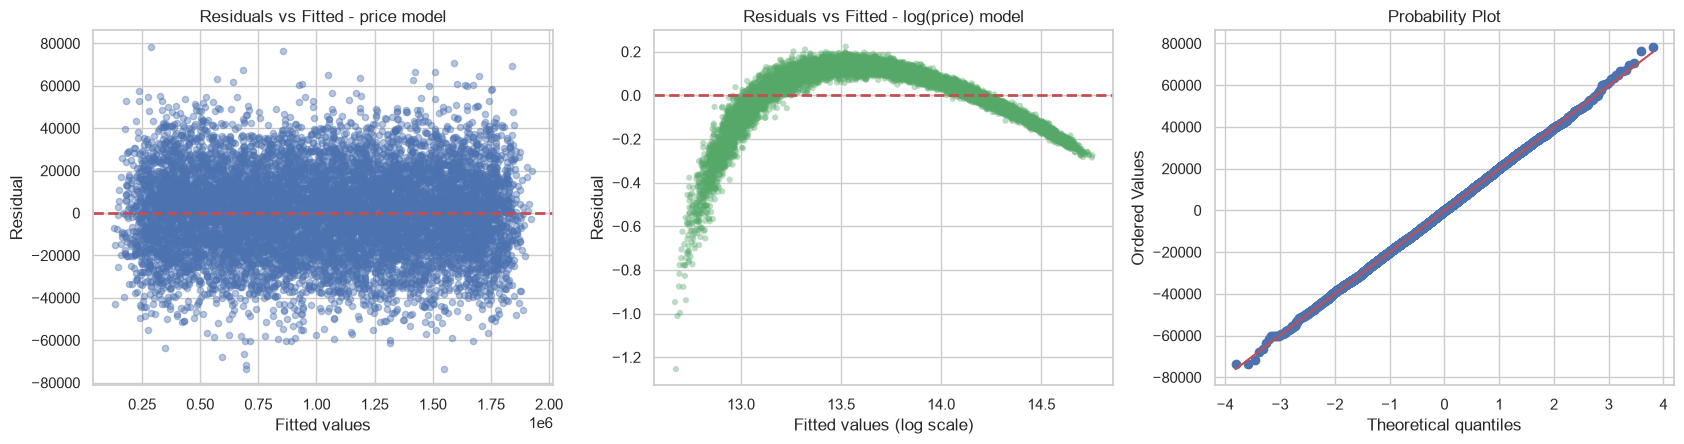

Residuals mean: -82.9 (should be ~0)
Skew:0.019 | Kurtosis: -0.037
corr(|residual|, fitted): -0.008 (near 0 = homoscedastic)


In [19]:
residuals = y_test - y_pred
residuals_log = np.log(y_test) - lin_log.predict(X_test)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
axes[0].scatter(y_pred, residuals, alpha=0.4, s=20)
axes[0].axhline(0, color="r", ls="--", lw=2)
axes[0].set_xlabel("Fitted values"); axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Fitted - price model")
axes[1].scatter(lin_log.predict(X_test), residuals_log, alpha=.4, s=20, color="#55A868", edgecolor="none")
axes[1].axhline(0, color="r", ls="--", lw=2)
axes[1].set_xlabel("Fitted values (log scale)"); axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs Fitted - log(price) model")
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[2])
plt.tight_layout(); plt.show()
print("Residuals mean: {:,.1f} (should be ~0)".format(residuals.mean()))
print("Skew:{:.3f} | Kurtosis: {:.3f}".format(stats.skew(residuals), stats.kurtosis(residuals)))
corr_rf = np.corrcoef(y_pred, np.abs(residuals))[0,1]
print(f"corr(|residual|, fitted): {corr_rf:.3f} (near 0 = homoscedastic)")

In [ ]:
_Observation: The predicted prices are very close to the actual prices. The model performs very well, with an score of 0.998.About98.3% of the prediction are within 10% of the actual price,showing that the model is high accurate.

Coefficients Analysis

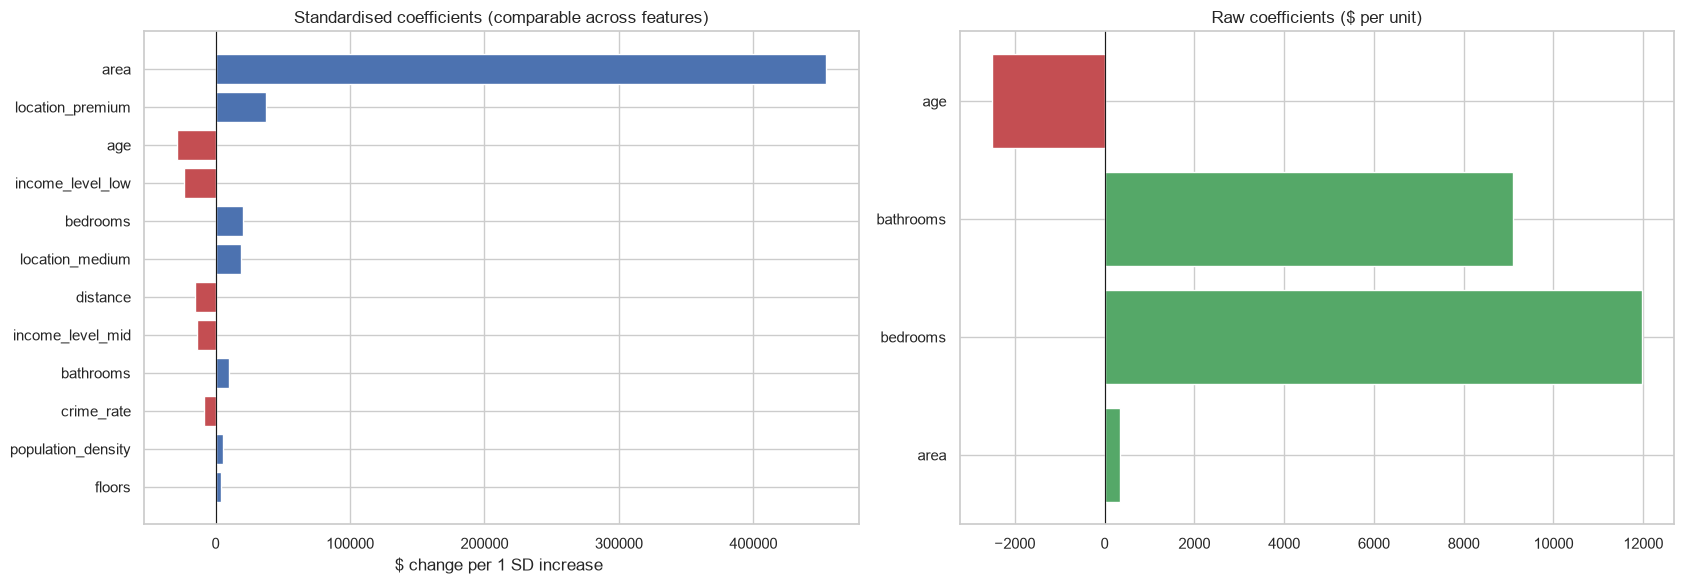

In [9]:
coefs = pd. DataFrame({"features": X.columns, "coefficient":lin.coef_})

#stanadardisec coefficients: refit on z-scored features
scaler = StandardScaler()
xs_train = scaler.fit_transform(X_train)
lin_std = LinearRegression().fit(xs_train, y_train)
coefs["std_coefficient"] = lin_std.coef_
coefs["abs_std"] = coefs["std_coefficient"].abs()
coefs = coefs.sort_values("abs_std", ascending=False)
fig, axes =plt.subplots(1, 2, figsize=(17, 6))
top = coefs.head(12).iloc[::-1]
axes[0].barh(top["features"], top["std_coefficient"], color=["#C44E52" if v <0 else "#4C72B0" for v in top["std_coefficient"]])
axes[0].axvline(0, color="k", lw=.8)
axes[0].set_title("Standardised coefficients (comparable across features)")
axes[0].set_xlabel("$ change per 1 SD increase ")
raw = coefs.set_index("features") .loc[[c for  c in ["area","bedrooms","bathrooms", "Parking", "Stories","age", "city", " furnishing", "main road","guest room", "basement", "water supply", "air conditions", "preferred tenant", "locality rating", "price"] if c in coefs["features"].values]]
axes[1].barh(raw.index, raw["coefficient"], color=["#C44E52" if v < 0 else "#55A868" for v in raw["coefficient"]])
axes[1].axvline(0, color="k" , lw=.8)
axes[1].set_title("Raw coefficients ($ per unit)")
plt.tight_layout(); plt.show()

Observation: We can see the Area  has the strongest positive effects on price. Age and some other features have smaller or negative effects on price.


In [10]:
coefficient_table = coefs. copy()
print("Regression Coefficients")
display(coefficient_table.round(2))

Regression Coefficients


,features,coefficient,std_coefficient,abs_std
0,area,350.10,454026.97,454026.97
17,location_premium,80256.43,37803.82,37803.82
4,age,-2504.77,-28938.05,28938.05
18,income_level_low,-50077.17,-23588.24,23588.24
1,bedrooms,11961.86,20502.29,20502.29
16,location_medium,40240.01,18984.09,18984.09
5,distance,-1792.68,-14988.11,14988.11
19,income_level_mid,-29816.08,-14049.01,14049.01
2,bathrooms,9108.38,10161.05,10161.05
14,crime_rate,-3062.80,-8794.43,8794.43


Bonus Ridge and Lasso

In [11]:
alphas = np.logspace(-2, 4, 60)
pipelines = {
    "Linear Regression": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge (CV alpha)": make_pipeline(StandardScaler(), RidgeCV(alphas=alphas, cv=5)),
    "Lasso (CV alpha)": make_pipeline(StandardScaler(), LassoCV(alphas=alphas, cv=5,random_state=RANDOM_STATE, max_iter=5000))
     }
rows=[]
for name,pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    pred = pipe .predict(X_test)
    r = evaluate(name, y_test,pred)
    cvs = cross_val_score(pipe, X, y, cv=KFold(5, shuffle=True, random_state=RANDOM_STATE), scoring="r2")
    r["cv R2"] = cvs.mean()
    rows.append(r)

    comparison = pd.DataFrame(rows).set_index("Model")
    print(comparison.round(4). to_string(float_format=lambda v: f"{v:,.4f}"))

ridge_alpha = pipelines["Ridge (CV alpha)"].named_steps["ridgecv"].alpha_
lasso_model = pipelines["Lasso (CV alpha)"].named_steps["lassocv"]
lasso_alpha = lasso_model.alpha_
lasso_coef = lasso_model.coef_
print(f"\nChosen alpha - Ridge: {ridge_alpha:.3f} | Lasso: {lasso_alpha:.3f}")
print(f"Features zeroed out by Lasso:" f"{(lasso_coef ==0).sum()}/ {len(lasso_coef)}")
if (lasso_coef ==0).sum():
    print("Dropped:", list(X.columns[lasso_coef == 0]))

                               MSE        RMSE         MAE      R  MAPE %  cv R2
Model                                                                           
Linear Regression 397,637,450.3150 19,940.8488 15,954.1727 0.9981  2.0858 0.9981
                               MSE        RMSE         MAE      R  MAPE %  cv R2
Model                                                                           
Linear Regression 397,637,450.3150 19,940.8488 15,954.1727 0.9981  2.0858 0.9981
Ridge (CV alpha)  397,636,994.4782 19,940.8374 15,954.1664 0.9981  2.0858 0.9981
                               MSE        RMSE         MAE      R  MAPE %  cv R2
Model                                                                           
Linear Regression 397,637,450.3150 19,940.8488 15,954.1727 0.9981  2.0858 0.9981
Ridge (CV alpha)  397,636,994.4782 19,940.8374 15,954.1664 0.9981  2.0858 0.9981
Lasso (CV alpha)  397,634,178.0399 19,940.7667 15,954.0964 0.9981  2.0858 0.9981

Chosen alpha - Ridge: 0.131

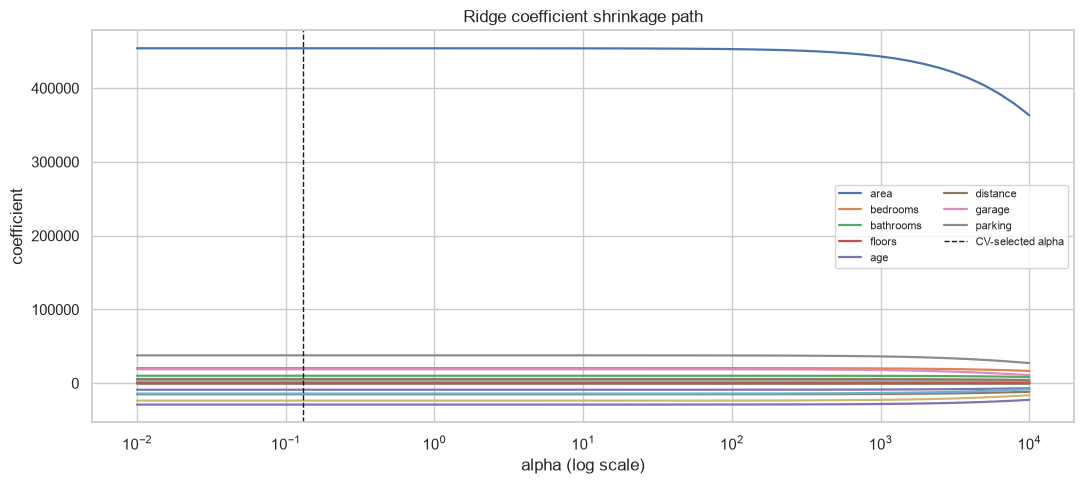

In [27]:
coef_path = []
Xs = StandardScaler().fit_transform(X_train)
for a in alphas:
     coef_path.append(Ridge(alpha=a).fit(Xs, y_train).coef_)
coef_path = np.array(coef_path)

plt.figure(figsize=(11, 5))
for i, col in enumerate(X.columns):
     plt.plot(alphas, coef_path[:, i], lw=1.6, label=col if i < 8 else None)
plt.xscale("log");plt.axvline(ridge_alpha, color="k", ls="--",lw=1, label="CV-selected alpha")
plt.xlabel("alpha (log scale)"); plt.ylabel("coefficient")
plt.title("Ridge coefficient shrinkage path")
plt.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()


In [ ]:
 Observation:The coefficients generally  increase as alpha increases. the model remains realtively stable for most variables, while one coefficient shows a sharp change at very high alpha values